In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

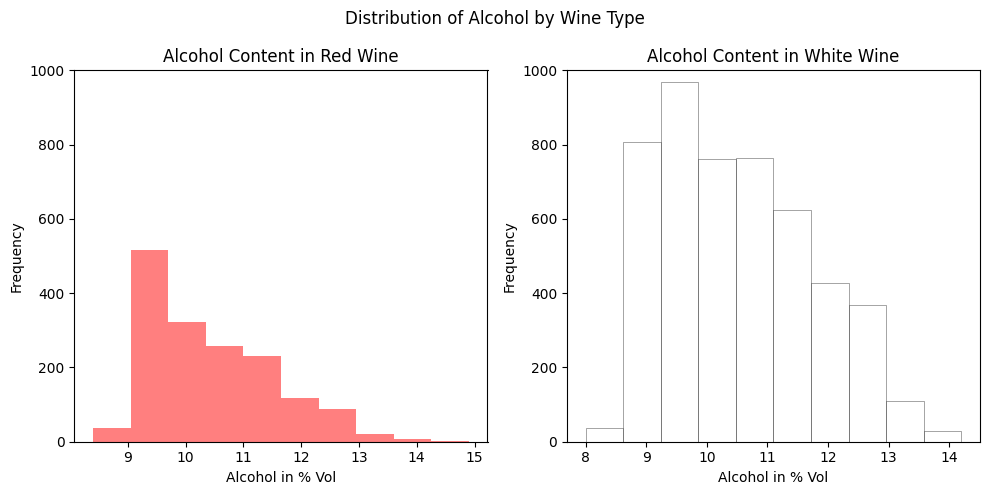

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [19]:
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [20]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\kyran\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 5s 991us/step - accuracy: 0.9086 - loss: 0.2991
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 4s 996us/step - accuracy: 0.9340 - loss: 0.1925
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 4s 812us/step - accuracy: 0.9487 - loss: 0.1446


In [22]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


In [ ]:
# ===== HYPERPARAMETER TUNING =====
# Definieer verschillende configuraties om te testen
configurations = [
    {'hidden_layers': [12, 8], 'epochs': 5, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [12, 8], 'epochs': 20, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [16, 8], 'epochs': 10, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [12, 6], 'epochs': 10, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [12, 8, 4], 'epochs': 10, 'learning_rate': 0.001, 'batch_size': 32},
    {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.0001, 'batch_size': 32},
    {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.01, 'batch_size': 32},
]

# Functie om een model met gegeven configuratie te trainen
def train_model_with_config(X_train, y_train, X_test, y_test, config):
    from tensorflow.keras.optimizers import Adam
    
    model = Sequential()
    model.add(Dense(config['hidden_layers'][0], activation='relu', input_dim=12))
    
    for hidden_units in config['hidden_layers'][1:]:
        model.add(Dense(hidden_units, activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_split=0.2,
        verbose=0
    )
    
    # Evalueer op test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    return {
        'config': config,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1],
    }

# Train alle modellen
print("Training different model configurations...")
results = []
for i, config in enumerate(configurations):
    print(f"Training config {i+1}/{len(configurations)}: {config}")
    result = train_model_with_config(X_train, y_train, X_test, y_test, config)
    results.append(result)

print("Done!")

Training different model configurations...
Training config 1/8: {'hidden_layers': [12, 8], 'epochs': 5, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\kyran\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training config 2/8: {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\kyran\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training config 3/8: {'hidden_layers': [12, 8], 'epochs': 20, 'learning_rate': 0.001, 'batch_size': 32}


...

Training config 7/8: {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.0001, 'batch_size': 32}


c:\Users\kyran\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training config 8/8: {'hidden_layers': [12, 8], 'epochs': 10, 'learning_rate': 0.01, 'batch_size': 32}


c:\Users\kyran\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done!


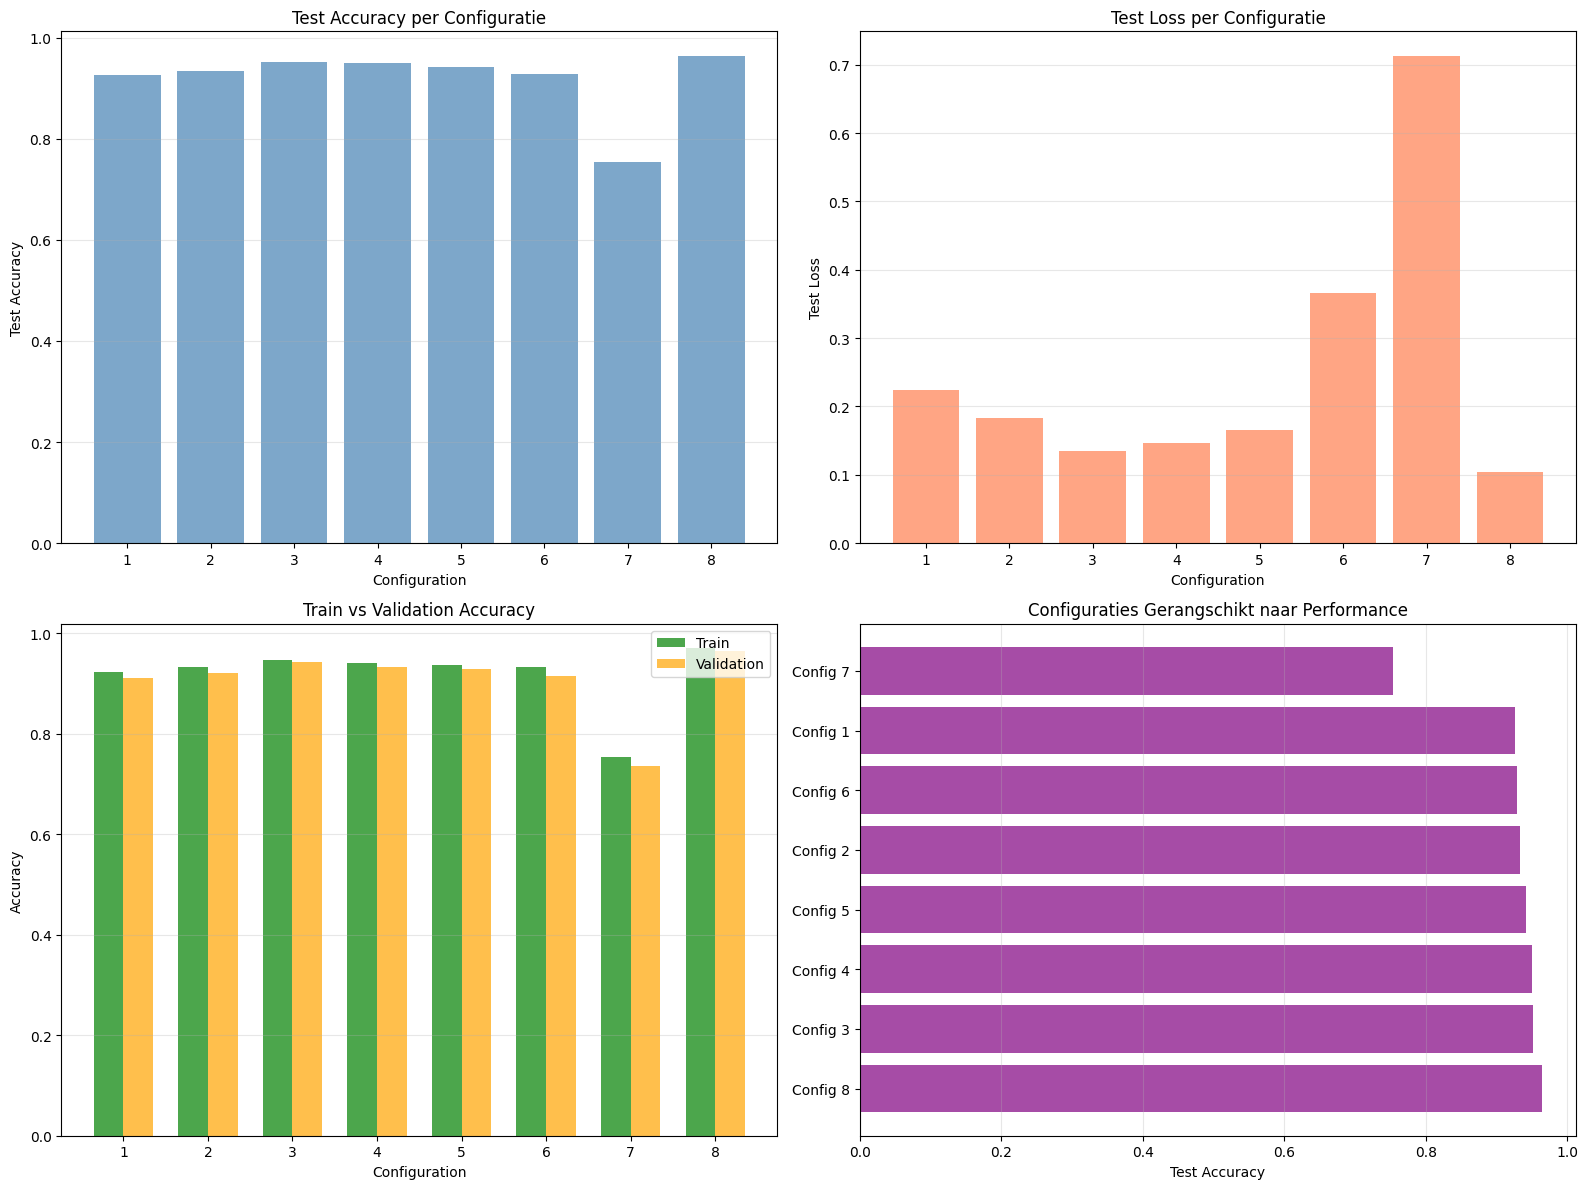


=== TOP 3 BESTE CONFIGURATIES ===

1. Test Accuracy: 0.9642, Test Loss: 0.1038
   Hidden Layers: [12, 8]
   Epochs: 10, Learning Rate: 0.01, Batch Size: 32

2. Test Accuracy: 0.9520, Test Loss: 0.1352
   Hidden Layers: [12, 8]
   Epochs: 20, Learning Rate: 0.001, Batch Size: 32

3. Test Accuracy: 0.9502, Test Loss: 0.1461
   Hidden Layers: [16, 8]
   Epochs: 10, Learning Rate: 0.001, Batch Size: 32


In [24]:
# ===== VISUALISEER RESULTATEN =====
# Maak labels voor elke configuratie
labels = []
for i, config in enumerate(configurations):
    label = f"Layers:{str(config['hidden_layers']).replace('[', '').replace(']', '')} | Epochs:{config['epochs']} | LR:{config['learning_rate']}"
    labels.append(label)

# Extract metrieke
test_accuracies = [r['test_accuracy'] for r in results]
test_losses = [r['test_loss'] for r in results]
val_accuracies = [r['final_val_acc'] for r in results]
train_accuracies = [r['final_train_acc'] for r in results]

# Grafiek 1: Test Accuracy vergelijking
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
axes[0, 0].bar(range(len(results)), test_accuracies, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Configuration')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy per Configuratie')
axes[0, 0].set_xticks(range(len(results)))
axes[0, 0].set_xticklabels(range(1, len(results)+1))
axes[0, 0].grid(axis='y', alpha=0.3)

# Test Loss
axes[0, 1].bar(range(len(results)), test_losses, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Configuration')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss per Configuratie')
axes[0, 1].set_xticks(range(len(results)))
axes[0, 1].set_xticklabels(range(1, len(results)+1))
axes[0, 1].grid(axis='y', alpha=0.3)

# Train vs Validation Accuracy
x = np.arange(len(results))
width = 0.35
axes[1, 0].bar(x - width/2, train_accuracies, width, label='Train', color='green', alpha=0.7)
axes[1, 0].bar(x + width/2, val_accuracies, width, label='Validation', color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Configuration')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Train vs Validation Accuracy')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(range(1, len(results)+1))
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Rank van configuraties (best performance)
sorted_indices = np.argsort(test_accuracies)[::-1]
sorted_labels = [f"Config {sorted_indices[i]+1}" for i in range(len(results))]
sorted_accuracies = [test_accuracies[i] for i in sorted_indices]

axes[1, 1].barh(sorted_labels, sorted_accuracies, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Test Accuracy')
axes[1, 1].set_title('Configuraties Gerangschikt naar Performance')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Toon top 3 beste configuraties
print("\n=== TOP 3 BESTE CONFIGURATIES ===")
for rank, idx in enumerate(sorted_indices[:3], 1):
    config = configurations[idx]
    print(f"\n{rank}. Test Accuracy: {test_accuracies[idx]:.4f}, Test Loss: {test_losses[idx]:.4f}")
    print(f"   Hidden Layers: {config['hidden_layers']}")
    print(f"   Epochs: {config['epochs']}, Learning Rate: {config['learning_rate']}, Batch Size: {config['batch_size']}")